# **REPURCHASE PREDICTION MODEL**

**What:** A model that predicts whether a customer will buy again in the next 90 days

**Dataset:** Real e-commerce
transactions

**Algorithm:** Random Forest

**Steps:**
1. Clean the data
2. Feature engineering
3. Define the target
4. Train the model
5. Read the output

# Setup

Import tools



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded.")

All libraries loaded.


# Load the data

Real ecommerce data from github - https://raw.githubusercontent.com/mar-antaya/ml-portfolio-course/main/ecommerce_data.csv

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/mar-antaya/ml-portfolio-course/main/ecommerce_data.csv')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: 8,205 rows x 7 columns

Columns: ['CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice', 'TotalAmount', 'Country', 'ProductCategory']

First 5 rows:


,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalAmount,Country,ProductCategory
0,C0045,2022-08-24 00:00:00,2,39.69,79.39,UK,Books
1,C0757,2022-07-01 00:00:00,1,414.09,414.09,Netherlands,Sports
2,C1643,2022-01-05 00:00:00,1,358.44,358.44,NaN,Sports
3,C0133,2023-07-01 00:00:00,1,150.21,150.21,UK,Clothing
4,C0941,2022-12-10 00:00:00,1,222.65,222.65,UK,Sports


In [15]:
# Investigate the data quality

print('************ DATA QUALITY CHECK *****************')
print(f'\nTotal transactions: {len(df):,}')
print(f'\nUnique customers: {df['CustomerID'].nunique():,}')
print(f'\nDate range: {df['InvoiceDate'].min()} ==> {df['InvoiceDate'].max()}')

print(f'\n*** Missing values: ***')
for col in df.columns:
  missing = df[col].isnull().sum()
  if missing > 0:
    print(f'{col}: {missing:,} missing')

print(f'\n*** Negative values: ***')
print(f'Negative quantities: {(df['Quantity'] <=0).sum():,}')
print(f'Negative prices: {(df['UnitPrice'] <=0).sum():,}')

************ DATA QUALITY CHECK *****************

Total transactions: 8,205

Unique customers: 1,847

Date range: 2022-01-01 00:00:00 ==> 2023-12-31 00:00:00

*** Missing values: ***
CustomerID: 16 missing
Country: 1,339 missing

*** Negative values: ***
Negative quantities: 65
Negative prices: 24


# 1. Clean the data
Important things to fix:
- Drop rows with missing customerIDs. Can't predict for unknown customers
- Remove negative or zero quantities
- Filter out negative or zero prices

In [18]:
print(f'*** Before Cleaning: {len(df):,} rows***')

# make a copy of the data to be used for processing
df_clean = df.copy()

# convert dates
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# drop rows with missing customerIDs
df_clean = df_clean.dropna(subset=['CustomerID'])

# remove returns (negatives and zeros)
df_clean = df_clean[df_clean['Quantity'] > 0]

# remove bad prices (negatives and zeros)
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Create a total amount per transaction column
if 'TotalAmount' not in df_clean.columns:
  df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'*** After Cleaning: {len(df_clean):,} rows***')
print(f'\nRows Removed: {len(df) - len(df_clean):,}')
print(f'\nPredictable Customers: {df_clean['CustomerID'].nunique():,}')


*** Before Cleaning: 8,205 rows***
*** After Cleaning: 8,100 rows***

Rows Removed: 105

Predictable Customers: 1,840


# 2. Feature Engineering

Focusing on the following metrics:
- **R - Recency:** When did they last buy? Focus on recent buyers.
- **F - Frequency:** How many times have they bought? Focus on repeat buyers.
- **M - Monetary:** How much have they spent in total? Focus on higer spenders.

In [20]:
# split the data by time

# Features = first 9 months, Target = last 3 months
cutoff = df_clean['InvoiceDate'].min() + pd.DateOffset(months=9)
df_features = df_clean[df_clean['InvoiceDate'] <= cutoff].copy()
df_target = df_clean[df_clean['InvoiceDate'] > cutoff].copy()

print(f'Feature window: {df_features['InvoiceDate'].min().date()} ==> {df_features['InvoiceDate'].max().date()}')
print(f'Target window: {df_target['InvoiceDate'].min().date()} ==> {df_target['InvoiceDate'].max().date()}')

# perform RFM analysis on the feature window only
feature_date = cutoff + pd.Timedelta(days=1)

# for each customer
rfm = df_features.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (feature_date - x.max()).days),
    Frequency = ('TotalAmount', 'count'),
    Monetary = ('TotalAmount', 'sum')
).round(2)

Feature window: 2022-01-01 ==> 2022-10-01
Target window: 2022-10-02 ==> 2023-12-31


In [26]:
# summary of the customer base
print('********** CUSTOMER BASE SUMMARY ********')
print(f'\nRecency (days since the last purchase):')
print(f'Average: {rfm['Recency'].mean():.0f} days')
print(f'Most Recent: {rfm['Recency'].min():.0f} day(s) ago')
print(f'Least Recent: {rfm['Recency'].max():.0f} day(s) ago')

print(f'\nFrequency (number of purchases):')
print(f'Average: {rfm['Frequency'].mean():.1f} purchases')
print(f'Most Loyal: {rfm['Frequency'].max()} purchases')

print(f'\nMonetary (total spent):')
print(f'Average: ${rfm['Monetary'].mean():.2f}')
print(f'Highest: ${rfm['Monetary'].max():.2f}')

********** CUSTOMER BASE SUMMARY ********

Recency (days since the last purchase):
Average: 87 days
Most Recent: 1 day(s) ago
Least Recent: 274 day(s) ago

Frequency (number of purchases):
Average: 2.6 purchases
Most Loyal: 22 purchases

Monetary (total spent):
Average: $559.27
Highest: $4310.80


# 3. Define the Targets

Will this customer buy again in 90 days? **YES or NO.**

Perform a **binary classification** where each customer gets a label as either:
```
- 1 => Yes, they came back
- 0 => No, they didn't
```
As the data is split by time, features are from the past trends while targets are from the future data.



In [36]:
future_buyers = set(df_target['CustomerID'].unique())
# an already existing customerID is a returning customer
rfm['WillBuyAgain'] = rfm.index.map(lambda x: 1 if x in future_buyers else 0)

print(f'RFM table: {len(rfm):,} customers, 3 features each')
print(f"Will buy again: {rfm['WillBuyAgain'].sum():,} ({rfm['WillBuyAgain'].mean()*100:.0f}%)")
print(f"Won't buy again: {(rfm['WillBuyAgain'] == 0).sum():,} ({(1 - rfm['WillBuyAgain'].mean())*100:.0f}%)")

print(f'\Sample first 10 customers:')
rfm.head(10)

RFM table: 1,368 customers, 3 features each
Will buy again: 504 (37%)
Won't buy again: 864 (63%)
\Sample first 10 customers:


,Recency,Frequency,Monetary,WillBuyAgain
CustomerID,,,,
C0001,15,4,421.60,0
C0002,36,2,167.73,1
C0003,3,2,99.65,1
C0005,162,1,68.88,0
C0006,108,1,135.79,0
C0007,202,1,209.35,0
C0011,99,1,33.60,1
C0012,99,1,109.84,0
C0013,157,1,240.28,0


# 4. Train the Model

Feed the RFM features into a Random Forest, for each decision tree to vote on the answer.

In [38]:
# separate features(x) and targets(y)
x = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['WillBuyAgain']

# 80:20 split into training and test data respectively
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print(f'Training on: {len(x_train):,} customers')
print(f'Testing on: {len(x_test):,} customers')

# train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

Training on: 1,094 customers
Testing on: 274 customers


RandomForestClassifier(random_state=42)

# 5. Read the Output

Every customer gets a probability score between 0 and 1.
- **High probability score:** customer is likely to come back
- **Low probability score:** business is at risk of losing this customer.

In [43]:
# make predictions using test data
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# check model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.1f}%\n')

# results table
results = pd.DataFrame({
    'Recency (days)': x_test['Recency'].values,
    'Frequency': x_test['Frequency'].values,
    'Monetary($) ': x_test['Monetary'].values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': (y_prob * 100).round(1)
})

results['Label'] = results['Probability'].apply(
    lambda x: '🟢 Likely' if x >= 50 else '🔴 At Risk'
)

print('********** CUSTOMER PREDICTIONS **********')
print(results.head(15).to_string(index=False))

Model Accuracy: 73.0%

********** CUSTOMER PREDICTIONS **********
 Recency (days)  Frequency  Monetary($)   Actual  Predicted  Probability     Label
             24          2       1370.04       1          1         72.0  🟢 Likely
            185          2        397.07       0          0          2.0 🔴 At Risk
             28          1        156.62       1          0         13.0 🔴 At Risk
            166          2        919.84       0          0         24.0 🔴 At Risk
            188          1        188.46       0          0         16.0 🔴 At Risk
            252          1        149.10       0          0         10.0 🔴 At Risk
             35          4        701.09       1          1         54.0  🟢 Likely
             14          5       1853.41       1          1         77.0  🟢 Likely
            104          1         30.94       1          0          6.0 🔴 At Risk
             33          2        337.93       0          1         88.0  🟢 Likely
             70      

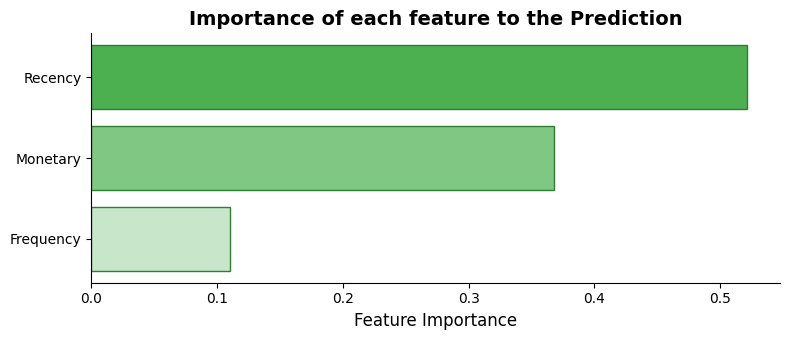

In [44]:
# most important features to the model
importance = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fog, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#c8e6c9', '#81c784', '#4caf50']
ax.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='#2e7d32')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Importance of each feature to the Prediction', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()